In [ ]:
import yfinance as yf

# Defining self similarity
ticker = 'AAPL'
start_date = '2024-01-01'
end_date = '2024-12-31'
start_hour = '2025-11-24'
end_hour = '2025-11-25'

# Downloading data
day_level_data = yf.download(ticker, start = start_date, end = end_date, multi_level_index=False)
hour_level_data = yf.download(ticker, start = start_date, end = end_date, interval = '1h', multi_level_index=False)
minute_level_data = yf.download(ticker, start = start_hour, end = end_hour, interval = '1m', multi_level_index=False)


/var/folders/zg/dk0qffx55tj5q4d2hvpp5m2c0000gn/T/ipykernel_38191/2679614770.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  minute_level_data = yf.download(ticker, start = start_hour, end = end_hour, interval = '1m', multi_level_index=False)
[*********************100%***********************]  1 of 1 completed


In [61]:
import pandas as pd
# Test 1: Distribution of returns
day_returns = pd.DataFrame(day_level_data['Close'].pct_change()).dropna().reset_index()['Close']
day_returns
hourly_returns = pd.DataFrame(hour_level_data['Close'].pct_change()).dropna().reset_index()['Close']
num_days = len(day_returns)
correlations = pd.DataFrame()
for i in range(len(hourly_returns)- num_days):
    window_start, window_end = i, i + num_days
    hourly_data = hourly_returns.iloc[window_start:window_end]
    hourly_data = hourly_data.values
    day_data = day_returns.values
    correlation_with_window = np.corrcoef(day_data, hourly_data)[0][1]
    if pd.isna(correlation_with_window):
        print(window_start, window_end)
        print(hourly_data)
    temp_df = pd.DataFrame(
        {
            'window_start': [window_start],
            'window_end': [window_end],
            'correlation': correlation_with_window
        }
    )

    correlations = pd.concat([correlations, temp_df])


correlations



# Test 2: Autocorrection structure
# Test 3: Clustering of volatility
# Test 4: Self similarity of volatility
# Test 5: Hurst exponent is stable across scales


,window_start,window_end,correlation
0,0,250,0.063883
0,1,251,-0.042043
0,2,252,-0.055458
0,3,253,0.002448
0,4,254,-0.021419
...,...,...,...
0,1489,1739,0.078332
0,1490,1740,-0.033480
0,1491,1741,-0.029884
0,1492,1742,-0.023000


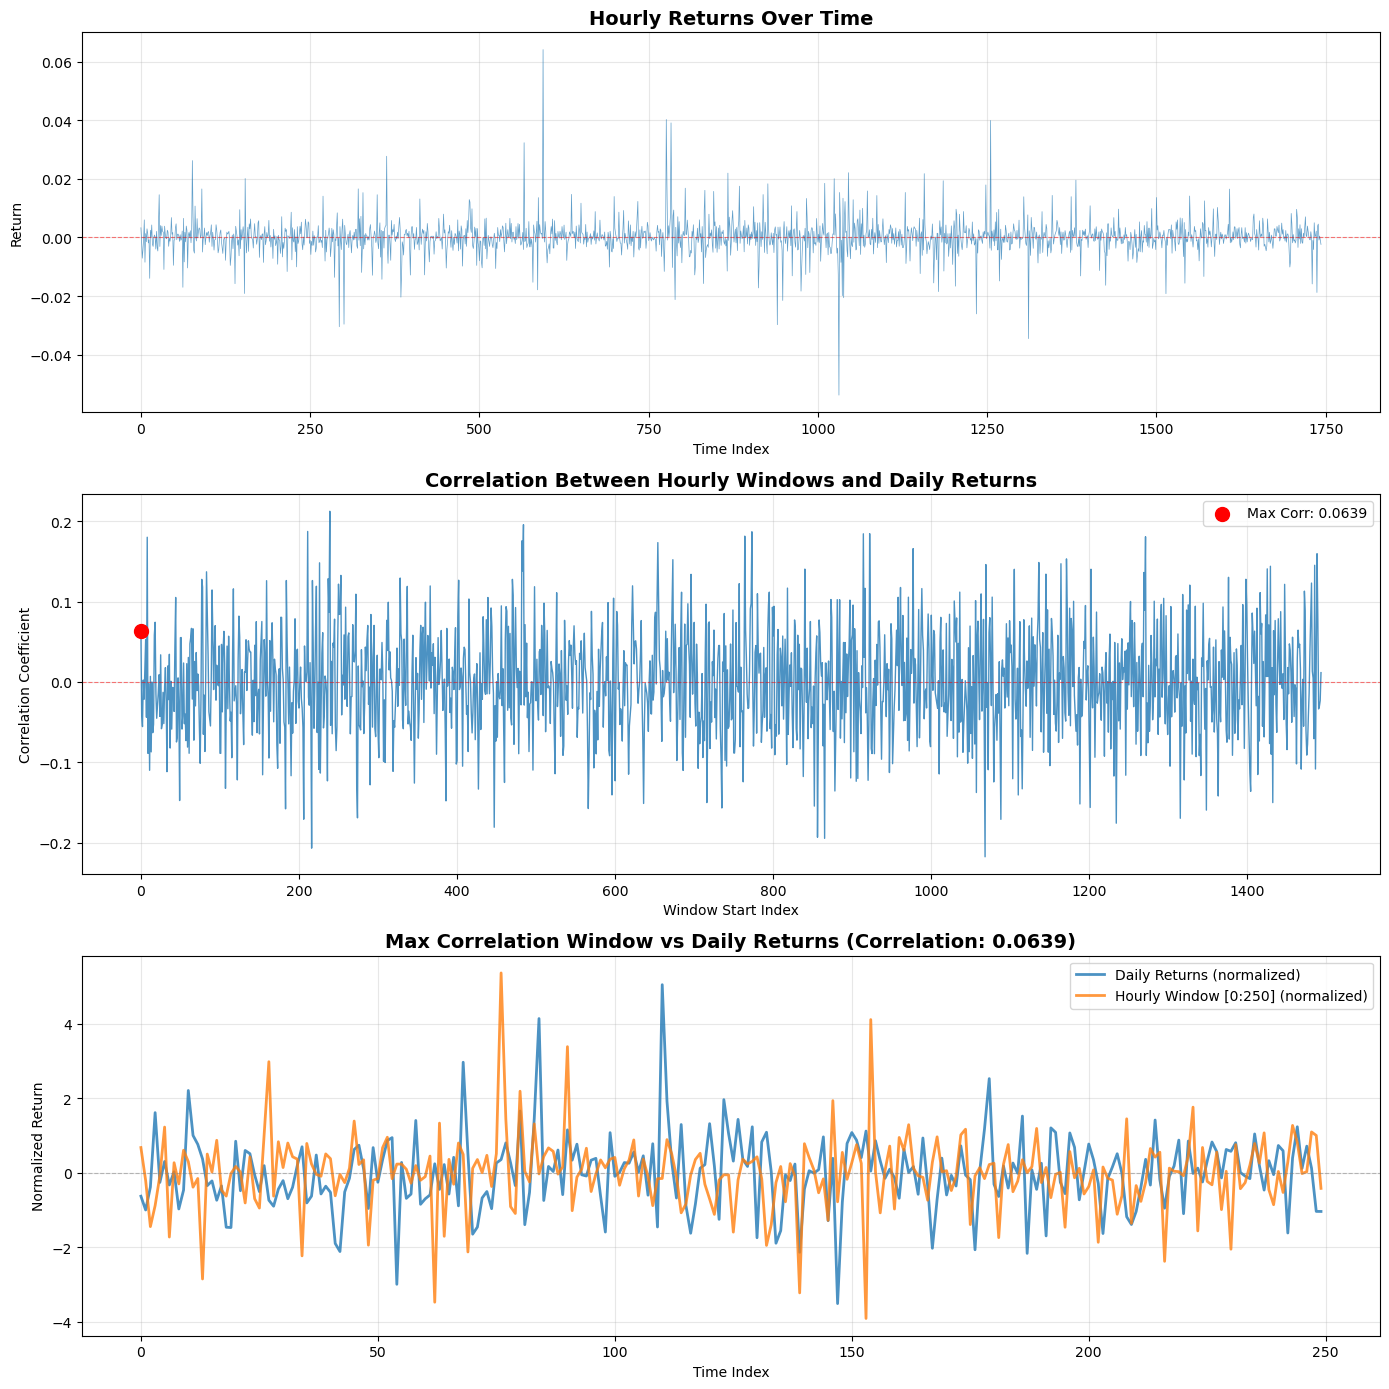


Correlation Statistics:
Mean correlation: -0.0000
Std correlation: 0.0636
Max correlation: 0.0639 at window [0:250]
Min correlation: -0.2173


In [72]:
import matplotlib.pyplot as plt

# Create a figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 14))

# Plot 1: Hourly returns over time
ax1.plot(hourly_returns.values, linewidth=0.5, alpha=0.7)
ax1.set_title('Hourly Returns Over Time', fontsize=14, fontweight='bold')
ax1.set_xlabel('Time Index')
ax1.set_ylabel('Return')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='r', linestyle='--', linewidth=0.8, alpha=0.5)

# Plot 2: Correlation of different windows with day returns
ax2.plot(correlations['window_start'].values, correlations['correlation'].values, linewidth=1, alpha=0.8)
ax2.set_title('Correlation Between Hourly Windows and Daily Returns', fontsize=14, fontweight='bold')
ax2.set_xlabel('Window Start Index')
ax2.set_ylabel('Correlation Coefficient')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='r', linestyle='--', linewidth=0.8, alpha=0.5)

# Find the window with maximum correlation
max_corr_idx = correlations['correlation'].idxmax()
max_corr_row = correlations.loc[max_corr_idx]
max_window_start = int(max_corr_row['window_start'].iloc[0])
max_window_end = int(max_corr_row['window_end'].iloc[0])
max_correlation = float(max_corr_row['correlation'].iloc[0])

# Mark the max correlation point on the correlation plot
ax2.scatter([max_window_start], [max_correlation], color='red', s=100, zorder=5, label=f'Max Corr: {max_correlation:.4f}')
ax2.legend()

# Plot 3: Compare max correlation window with daily returns
max_window_hourly = hourly_returns.iloc[max_window_start:max_window_end].values
day_returns_values = day_returns.values

# Normalize both series to compare shapes
max_window_hourly_norm = (max_window_hourly - np.mean(max_window_hourly)) / np.std(max_window_hourly)
day_returns_norm = (day_returns_values - np.mean(day_returns_values)) / np.std(day_returns_values)

x_axis = range(len(day_returns_values))
ax3.plot(x_axis, day_returns_norm, label='Daily Returns (normalized)', linewidth=2, alpha=0.8)
ax3.plot(x_axis, max_window_hourly_norm, label=f'Hourly Window [{max_window_start}:{max_window_end}] (normalized)', linewidth=2, alpha=0.8)
ax3.set_title(f'Max Correlation Window vs Daily Returns (Correlation: {max_correlation:.4f})', fontsize=14, fontweight='bold')
ax3.set_xlabel('Time Index')
ax3.set_ylabel('Normalized Return')
ax3.grid(True, alpha=0.3)
ax3.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax3.legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nCorrelation Statistics:")
print(f"Mean correlation: {correlations['correlation'].mean():.4f}")
print(f"Std correlation: {correlations['correlation'].std():.4f}")
print(f"Max correlation: {max_correlation:.4f} at window [{max_window_start}:{max_window_end}]")
print(f"Min correlation: {correlations['correlation'].min():.4f}")


np.float64(-0.033480274627197236)